In [1]:
import cobra
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import hdbscan
from pathlib import Path

In [2]:
gp_folder = Path('../../data/4_growth_phenotyping/')

In [3]:
model_universe_fn = gp_folder / 'carveme_universe_bacteria.xml'
model_universe = cobra.io.read_sbml_model(model_universe_fn)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-11-28


In [4]:
model_universe.optimize()
print(model_universe.summary())


Objective
1.0 Growth = 433.30021174478645

Uptake
------
    Metabolite          Reaction    Flux  C-Number C-Flux
    12ppd__R_e     EX_12ppd__R_e    1000         3  1.68%
      2ameph_e       EX_2ameph_e    1000         2  1.12%
       2obut_e        EX_2obut_e    1000         4  2.24%
         3mb_e          EX_3mb_e   195.2         5  0.55%
       4abut_e        EX_4abut_e    1000         4  2.24%
      4hphac_e       EX_4hphac_e    1000         8  4.47%
LalaDgluMdap_e EX_LalaDgluMdap_e   43.33        15  0.36%
       acnam_e        EX_acnam_e    1000        11  6.15%
     actn__R_e      EX_actn__R_e   283.8         4  0.63%
         akg_e          EX_akg_e    1000         5  2.79%
         amp_e          EX_amp_e   88.18        10  0.49%
        argp_e         EX_argp_e    1000         6  3.35%
      asn__L_e       EX_asn__L_e   104.4         4  0.23%
         ca2_e          EX_ca2_e   2.255         0  0.00%
         cit_e          EX_cit_e  0.2994         6  0.00%
     citr__L_e 

In [5]:
for r in model_universe.exchanges:
    r.lower_bound = 0
    # m,i = r.metabolites.popitem()
    # if 'C' in m.formula:
    #     r.lower_bound = 0
    #     sol = model.slim_optimize()
    #     if sol == 0:
    #         print(r.id, sol)

In [6]:
# M9
uptake = ['EX_glc__D_e', 'EX_nh4_e', 'EX_pi_e', 'EX_so4_e', 'EX_h2o_e', 'EX_h_e', 'EX_o2_e', 'EX_fe2_e', 'EX_fe3_e', 'EX_cobalt2_e', 'EX_ca2_e', 'EX_cl_e', 
       'EX_cu2_e','EX_k_e', 'EX_mg2_e', 'EX_mn2_e','EX_zn2_e', 'EX_mobd_e', 'EX_ni2_e', 'EX_na1_e']


model_universe.add_boundary(model_universe.metabolites.na1_e, 'exchange', lb = -1000, ub = 1000)
model_universe.add_boundary(model_universe.metabolites.ni2_e, 'exchange', lb = -1000, ub = 1000)
for r_id in uptake:
    model_universe.reactions.get_by_id(r_id).lower_bound = -1000
print(model_universe.optimize())

<Solution 64.600 at 0x168579cd0>


In [7]:
carbon_compounds = []
model_universe.reactions.EX_glc__D_e.lower_bound = 0
for r in model_universe.exchanges:
    with model_universe as model:
        model.reactions.get_by_id(r.id).bounds = (-10,1000)
        sol = model.slim_optimize()
        if sol > 0:
            carbon_compounds.append(r.id)

In [8]:
Nc = len(carbon_compounds)
fluxes = np.zeros((Nc, len(model_universe.reactions)))
for i in range(Nc):
    with model_universe as model:
        r_id = carbon_compounds[i]
        model.reactions.get_by_id(r_id).bounds = (-10,1000)
        solution = cobra.flux_analysis.pfba(model)
        fluxes[i,:] = solution.fluxes

# Cluster fluxes

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import scipy.cluster.hierarchy as spc
from sklearn.mixture import GaussianMixture

In [10]:
corr = np.corrcoef(fluxes)

In [11]:
pdist = spc.distance.pdist(corr)

In [12]:
linkage = spc.linkage(pdist, method='complete')
idx = spc.fcluster(linkage, 2, 'distance')
print(len(np.unique(idx)))

15


In [13]:
nz_fluxes = fluxes[:, ~(fluxes==0).all(axis =0)]

In [14]:
nz_fluxes.shape

(509, 2812)

In [15]:
binary_fluxes = np.sign(nz_fluxes)
bf2 = binary_fluxes[:, ~(binary_fluxes.std(axis =0) == 0)]

In [16]:
standard_scaler = StandardScaler()
sd_fluxes = standard_scaler.fit_transform(nz_fluxes)
sd_fluxes[508,:].mean()

np.float64(-0.029325777228680586)

23


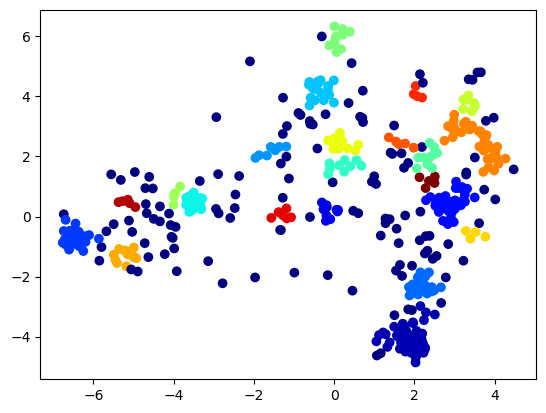

In [17]:
pca = PCA(n_components=2)
t = pca.fit_transform(bf2)
clustering = DBSCAN(eps=0.3, min_samples=4).fit(t)
plt.scatter(t[:,0], t[:,1], c = clustering.labels_, cmap = 'jet')
print(len(np.unique(clustering.labels_)))

In [18]:
fn_selected = '../../data/selected_carbon_sources.xlsx'
df_selected = pd.read_excel(fn_selected)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/selected_carbon_sources.xlsx'

In [ ]:
df_sel = df_selected.loc[df_selected['Selection']!= 0, :]


In [ ]:
met_index_dict = {}
for i, r_id in enumerate(carbon_compounds):
    r = model.reactions.get_by_id(r_id)
    m, j = r.metabolites.popitem()
    met_index_dict[m.id[:-2]] = i

In [ ]:
met_index_dict['glc__D']

259

xylan4_e
16


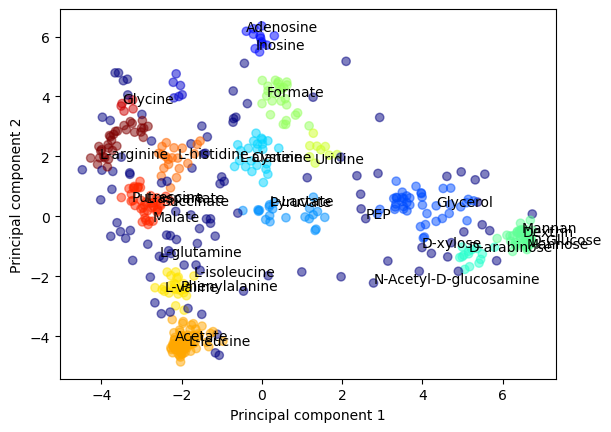

In [ ]:
clusterer = hdbscan.HDBSCAN()
clusterer.fit(t)
plt.scatter(t[:,0], t[:,1], c = clusterer.labels_, cmap = 'jet', alpha = 0.5)
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')

for i, row in df_sel.iterrows():
    met = row['Metabolite ID']
    try:
        idx = met_index_dict[met]
    except:
        print(met)
        pass
    else:
        plt.annotate(row['Metabolite'], (t[idx,0], t[idx,1]))
print(len(np.unique(clusterer.labels_)))

xylan4_e


Text(0, 0.5, 'tSNE 2')

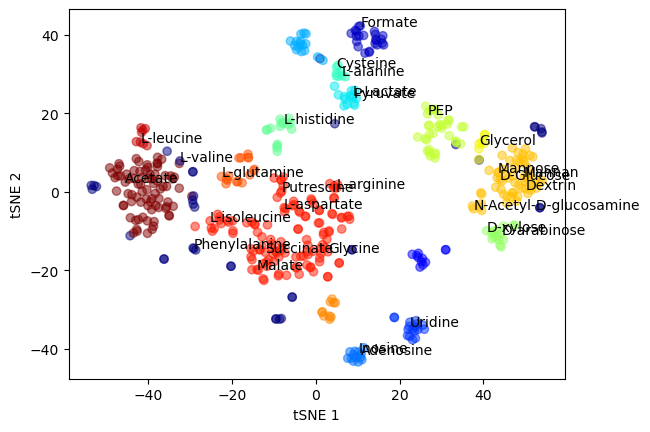

In [ ]:
X_embedded = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=15).fit_transform(bf2)
# clustering = DBSCAN(eps=2, min_samples=2 ).fit(X_embedded)
tsne_clust = hdbscan.HDBSCAN()
tsne_clust.fit(X_embedded)
plt.scatter(X_embedded[:,0], X_embedded[:,1], c = tsne_clust.labels_, cmap = 'jet', alpha = 0.5)
len(np.unique(clustering.labels_))
for i, row in df_sel.iterrows():
    met = row['Metabolite ID']
    try:
        idx = met_index_dict[met]
    except:
        print(met)
        pass
    else:
        plt.annotate(row['Metabolite'], (X_embedded[idx,0], X_embedded[idx,1]))
        
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')

In [ ]:
metabolites = []
metabolite_ids = []
for r_id in carbon_compounds:
    r = model_universe.reactions.get_by_id(r_id)
    m, i = r.metabolites.popitem()
    metabolites.append(m.name)
    metabolite_ids.append(m.id)


In [ ]:
df = pd.DataFrame()
df['Exchange'] = carbon_compounds
df['PCA cluster'] = clusterer.labels_
df['tSNE cluster'] = tsne_clust.labels_
df['Metabolite'] = metabolites
df['Metabolite ID'] = metabolite_ids
df.to_csv('Carbon_compounds_clustered.csv')

# Jaccard index

In [ ]:
import scipy as sp

In [ ]:
bool_df = np.abs(bf2).astype(bool)

In [ ]:
n = bool_df.shape[0]
J = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        J[i,j] = np.sum(bool_df[i,:]*bool_df[j,:])/np.sum(bool_df[i,:]+bool_df[j,:])

In [ ]:
J1d = [x for x in np.triu(J).flatten() if x!=0]

In [ ]:
# sp.cluster.hierarchy.dendrogram(Z)
# plt.show()

(array([2.8000e+01, 6.2000e+01, 4.9000e+02, 2.1100e+03, 6.9580e+03,
        1.9088e+04, 3.3310e+04, 4.0984e+04, 4.1216e+04, 3.8960e+04,
        2.9750e+04, 1.9826e+04, 1.2942e+04, 7.6540e+03, 3.8340e+03,
        1.1320e+03, 1.9800e+02, 3.0000e+01, 0.0000e+00, 5.0900e+02]),
 array([0.3398533 , 0.37286064, 0.40586797, 0.43887531, 0.47188264,
        0.50488998, 0.53789731, 0.57090465, 0.60391198, 0.63691932,
        0.66992665, 0.70293399, 0.73594132, 0.76894866, 0.80195599,
        0.83496333, 0.86797066, 0.900978  , 0.93398533, 0.96699267,
        1.        ]),
 <BarContainer object of 20 artists>)

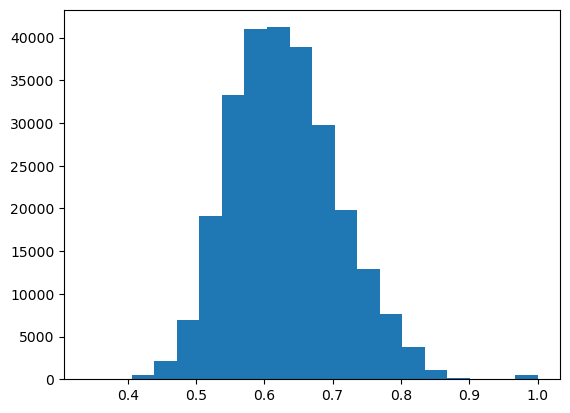

In [ ]:
plt.hist(J.flatten(), bins = 20)

/Users/ssulheim/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


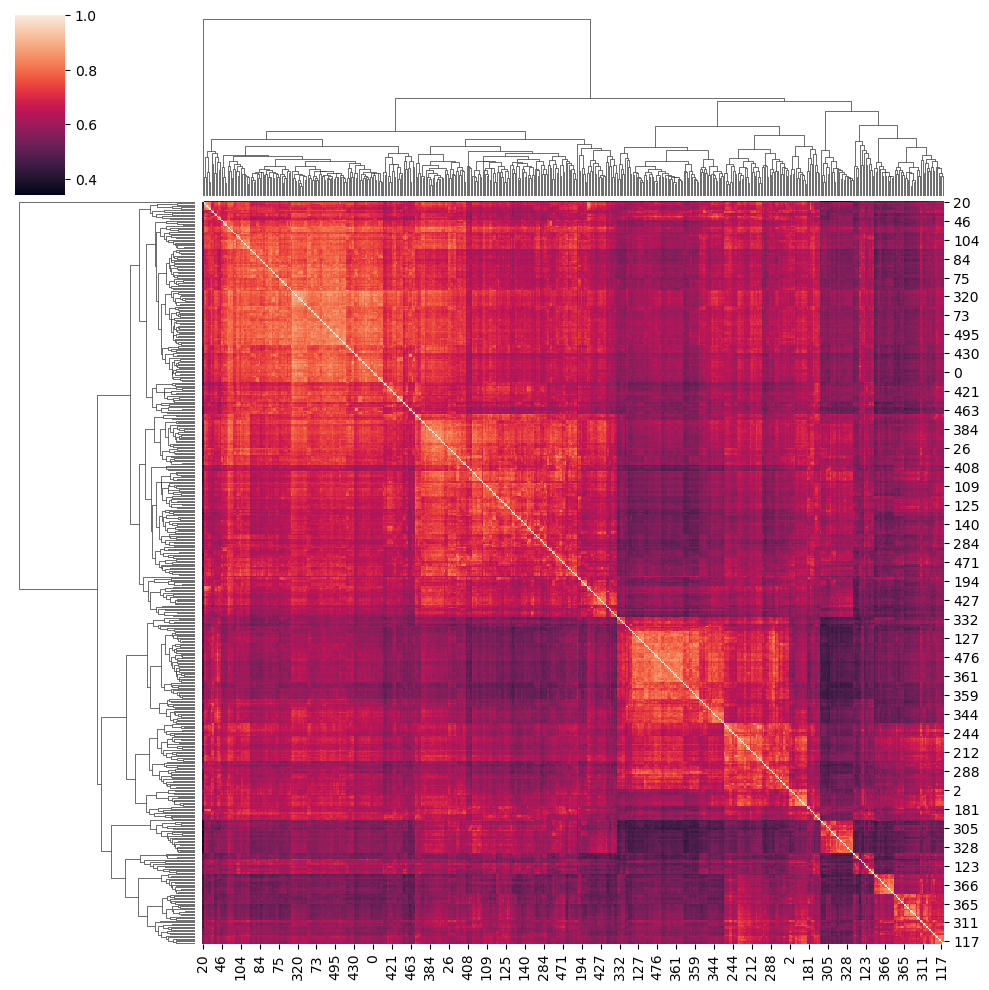

In [ ]:
sns.clustermap(J)

In [ ]:
np.sum(bool_df[1,:]*bool_df[0,:])/np.sum(bool_df[1,:]+bool_df[0,:])

0.7763157894736842

In [ ]:
jaccard = pairwise_distances(bf2[:,0], bf2[:,1], metric="jaccard", n_jobs=-1)

/Users/ssulheim/anaconda3/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2181: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


ValueError: Expected 2D array, got 1D array instead:
array=[False False  True False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False Fals

# Get MW and formula

In [ ]:
mets = ['ac', 'adn', 'cys__L', 'arab__D', 'glc__D', 'xyl__D', 
        'for', 'fum', 'glutar', 'glyc', 'gly', 'ins', 'ala__L', 
        'arg__L', 'asp__L', 'glu__L', 'gln__L', 'his__L', 'ile__L',
        'lac__L', 'leu__L', 'mal__L', 'mnl', 'man', 'inost',
        'orot', 'phe__L', 'pro__L', 'rib__D', 'sucr', 'uri']

In [ ]:
formulas = []
weights = []
N_carbons = []
for m in mets:
    m_id = m+'_c'
    met = model_universe.metabolites.get_by_id(m_id)
    formulas.append(met.formula)
    weights.append(met.formula_weight)
    N_carbons.append(met.elements['C'])

In [ ]:
print(weights)

[59.04402, 267.24132, 121.15818, 150.12990000000002, 180.15588, 150.12990000000002, 45.01744, 114.05628, 130.09874, 92.09382, 75.0666, 268.22608, 89.09318, 175.2089, 132.09474, 146.12132, 146.1445, 155.15456, 131.17291999999998, 89.07, 131.17291999999998, 132.07156, 182.17176, 180.15588, 180.15588, 155.08832, 165.18913999999998, 115.13046, 150.12990000000002, 342.29648, 244.20138]


In [ ]:
model

NameError: name 'model' is not defined

# DIV

In [ ]:
chemical_pairs = [
    ["Acetate", "D-glucose"],
    ["Formate", "L-isoleucine"],
    ["Glutarate", "Inosine"],
    ["Malate", "Formate"],
    ["Glycerol", "L-alanine"],
    ["L-glutamate", "Mannose"],
    ["L-histidine", "Mannose"],
    ["Mannitol", "Acetate"],
    ["myo-inositol", "L-glutamate"],
    ["Ribose", "Glutarate"],
    ["Sucrose", "L-histidine"],
    ["Glycerol", "Inosine"],
    ["L-alanine", "D-glucose"],
    ["Malate", "L-isoleucine"],
    ["Mannitol", "myo-inositol"]
]
capitalized_pairs = [[item.capitalize() for item in pair] for pair in chemical_pairs]

def has_duplicate_pairs(pair_list):
    seen_pairs = set()
    for pair in pair_list:
        # Sort the pair to handle cases like ['A', 'B'] and ['B', 'A']
        sorted_pair = tuple(sorted(pair))
        if sorted_pair in seen_pairs:
            return True
        seen_pairs.add(sorted_pair)
    return False

if has_duplicate_pairs(chemical_pairs):
    print("The list contains duplicate pairs.")
else:
    print("No duplicate pairs found.")

No duplicate pairs found.
